In [21]:
from pathlib import Path

result_path = Path("/mnt/data/dmtran/automated-exploit-generation/methodology/exploit-agent/logs")

In [22]:
error_ids = []
for file in result_path.glob("*/*/error.txt"):
    error_ids.append(file.parts[-3])
error_ids = list(set(error_ids))
len(error_ids)

2

In [23]:
import json

result_map = {
    "path-traversal": {"success": [], "failed": []},
    "redos": {"success": [], "failed": []},
    "command-injection": {"success": [], "failed": []},
    "code-injection": {"success": [], "failed": []},
    "prototype-pollution": {"success": [], "failed": []},
}

for file in result_path.glob("*/*/result.json"):
    log_path = Path('/'.join(file.parts[:-1])[1:]) / "logs.log"
    log_content = log_path.read_text()
    log_lines = log_content.splitlines()[1:]
    log_content = '\n'.join(log_lines)
    log_content = json.loads(log_content)
    vulnerability_type = log_content["vulnerability_type"]
    _id = log_content["id"]

    messages = json.loads(file.read_text())

    for message in messages:
        content = message["data"]["content"]
        if "Exploit successful" in content:
            result_map[vulnerability_type]["success"].append(_id)
        elif _id in error_ids:
            error_ids.pop(error_ids.index(_id))
        else:
            result_map[vulnerability_type]["failed"].append(_id)

In [24]:
# Convert each list in result_map to its length
for v_type, data in result_map.items():
    for key in ["success", "failed"]:
        data[key] = len(list(set(data[key])))

print("✅ Converted result_map (lists replaced with their lengths):")
result_map

✅ Converted result_map (lists replaced with their lengths):


{'path-traversal': {'success': 15, 'failed': 69},
 'redos': {'success': 3, 'failed': 40},
 'command-injection': {'success': 46, 'failed': 56},
 'code-injection': {'success': 16, 'failed': 29},
 'prototype-pollution': {'success': 49, 'failed': 97}}

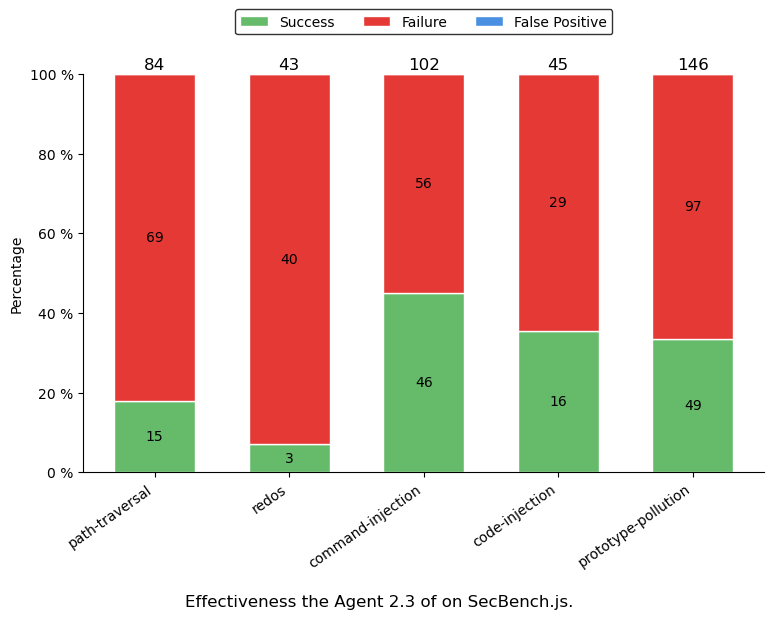

In [25]:
# Stacked percentage bar chart replicating the provided figure
import numpy as np
import matplotlib.pyplot as plt

# Data
categories = list(result_map.keys())
# Raw counts for each outcome per category
success = np.array([result["success"] for vuln, result in result_map.items()])
failure = np.array([result["failed"] for vuln, result in result_map.items()])
false_positive = np.array([0, 0, 0, 0, 0])

# Derived values
totals = success + failure + false_positive
success_pct = success / totals * 100.0
failure_pct = failure / totals * 100.0
fp_pct = false_positive / totals * 100.0

x = np.arange(len(categories))
bar_width = 0.6

colors = {
    "Success": "#66bb6a",      # green
    "Failure": "#e53935",      # red
    "False Positive": "#4a90e2",  # blue
}

fig, ax = plt.subplots(figsize=(8, 7))

# Stacked bars
bars_success = ax.bar(
    x, success_pct, bar_width, label="Success", color=colors["Success"], edgecolor="white"
)
bars_failure = ax.bar(
    x,
    failure_pct,
    bar_width,
    bottom=success_pct,
    label="Failure",
    color=colors["Failure"],
    edgecolor="white",
)
bars_fp = ax.bar(
    x,
    fp_pct,
    bar_width,
    bottom=success_pct + failure_pct,
    label="False Positive",
    color=colors["False Positive"],
    edgecolor="white",
)

# Helper to annotate count labels inside each segment (hide if segment is tiny)
def annotate_segment_counts(bars, counts, bottoms):
    for rect, count, bottom in zip(bars, counts, bottoms):
        height = rect.get_height()
        if height < 6:  # skip very small segments to avoid clutter
            continue
        ax.text(
            rect.get_x() + rect.get_width() / 2.0,
            bottom + height / 2.0,
            f"{int(count)}",
            ha="center",
            va="center",
            fontsize=10,
            color="black",
        )

annotate_segment_counts(bars_success, success, np.zeros_like(success_pct))
annotate_segment_counts(bars_failure, failure, success_pct)
annotate_segment_counts(bars_fp, false_positive, success_pct + failure_pct)

# Totals above bars
ax.set_ylim(0, 100)
for xi, total in zip(x, totals):
    ax.text(xi, 100.5, f"{int(total)}", ha="center", va="bottom", fontsize=12, clip_on=False)

# Axes formatting
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=35, ha="right")
ax.set_ylabel("Percentage")
ax.set_yticks(np.arange(0, 101, 20))
ax.set_yticklabels([f"{v} %" for v in np.arange(0, 101, 20)])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend on top
legend = ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    ncol=3,
    frameon=True,
)
legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("black")

# Caption below the chart
plt.figtext(
    0.5,
    0.01,
    "Effectiveness the Agent 2.3 of on SecBench.js.",
    ha="center",
    fontsize=12,
)

plt.tight_layout(rect=[0.02, 0.04, 1, 0.92])
plt.savefig("av2.3.sec.png", dpi=300, bbox_inches="tight")
plt.show()
